In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("flipkart_reviews_.csv")
df.head()

,Product_name,Review,Rating
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [ ]:
print(df.shape)

(2304, 3)


In [ ]:
print(df.columns)

Index(['Product_name', 'Review', 'Rating'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_name  2304 non-null   object
 1   Review        2304 non-null   object
 2   Rating        2304 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 54.1+ KB


In [ ]:
df.isnull().sum()

,0
Product_name,0
Review,0
Rating,0


In [ ]:
df.duplicated().sum()

np.int64(123)

In [ ]:
df.describe()

,Rating
count,2304.000000
mean,4.259549
std,1.180017
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
df.describe(include="object")

,Product_name,Review
count,2304,2304
unique,231,1358
top,"realme C25Y (Glacier Blue, 128 GB) (4 GB RAM)",Good
freq,20,47


In [ ]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].nunique())


Column: Product_name
231

Column: Review
1358

Column: Rating
5


In [ ]:
print(df.iloc[0])

Product_name    Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...
Review          Best under 60k Great performanceI got it for a...
Rating                                                          5
Name: 0, dtype: object


In [ ]:
df["Rating"].value_counts()

,count
Rating,
5,1382
4,552
1,184
3,140
2,46


In [ ]:
df["Review"].head()

,Review
0,Best under 60k Great performanceI got it for a...
1,Good perfomence...
2,Great performance but usually it has also that...
3,My wife is so happy and best product 👌🏻😘
4,"Light weight laptop with new amazing features,..."


Sentement


In [ ]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(rating_to_sentiment)
print(df.shape)
df.head()

(2304, 4)


,Product_name,Review,Rating,Sentiment
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,Positive
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,Positive
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,Positive
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,Positive
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,Positive


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_name  2304 non-null   object
 1   Review        2304 non-null   object
 2   Rating        2304 non-null   int64 
 3   Sentiment     2304 non-null   object
dtypes: int64(1), object(3)
memory usage: 72.1+ KB


,0
Product_name,0
Review,0
Rating,0
Sentiment,0


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
print(df.shape)

(2181, 4)


In [ ]:
df.describe()

,Rating
count,2181.000000
mean,4.293443
std,1.152619
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,1857
Negative,206
Neutral,118


Sentiment Distribution

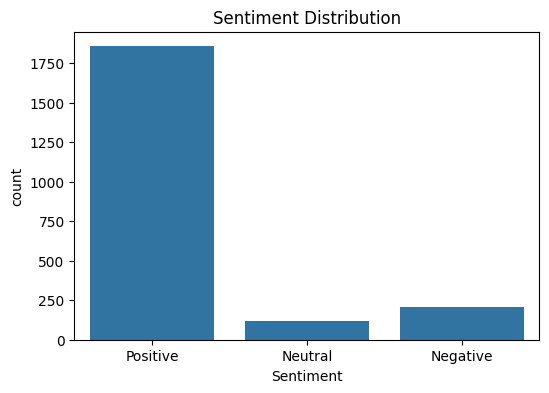

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Sentiment", data=df)

plt.title("Sentiment Distribution")
plt.show()

Rating Distribution

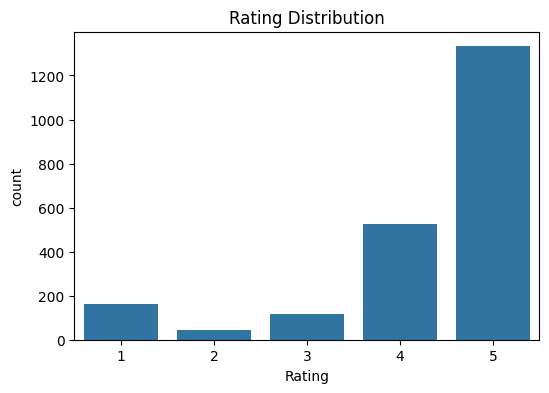

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Rating", data=df)

plt.title("Rating Distribution")
plt.show()

Review Length Analysis

In [ ]:
df["Review_Length"] = df["Review"].astype(str).apply(len)
df.head()

,Product_name,Review,Rating,Sentiment,Review_Length
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,Positive,324
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,Positive,18
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,Positive,215
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,Positive,40
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,Positive,71


Distribution of Review Length

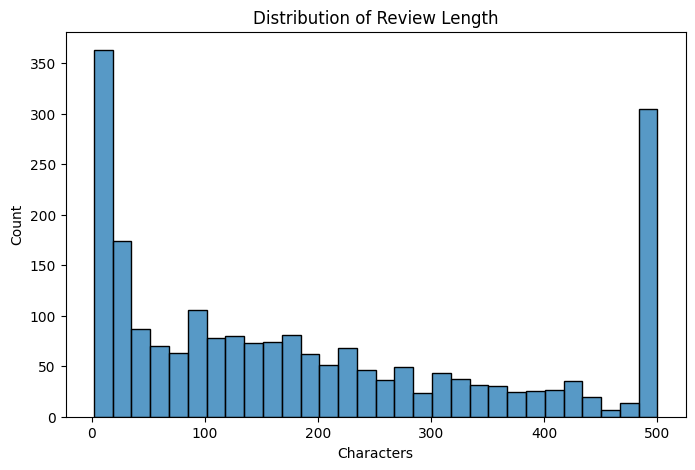

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Review_Length"], bins=30)

plt.title("Distribution of Review Length")
plt.xlabel("Characters")
plt.show()

Average Review Length by Sentiment

In [ ]:
df.groupby("Sentiment")["Review_Length"].mean()


,Review_Length
Sentiment,
Negative,176.995146
Neutral,199.754237
Positive,196.745288


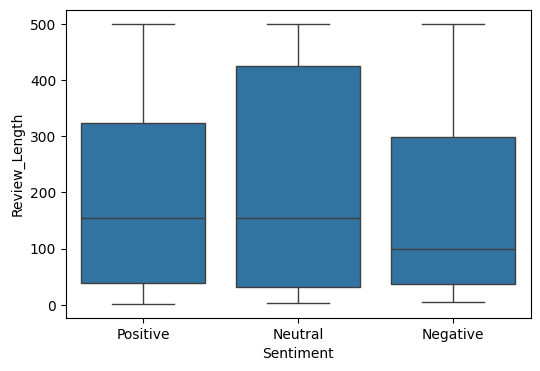

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Sentiment",
            y="Review_Length",
            data=df)

plt.show()

Most Reviewed Products

In [ ]:
df["Product_name"].value_counts().head(10)

,count
Product_name,
"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)",10
"ASUS VivoBook 15 (2021) Core i3 10th Gen - (8 GB/512 GB SSD/Windows 11 Home) X515JA-EJ362WS Thin and Light Laptop (15.6 inch, Transparent Silver, 1.80 kg, With MS Office)",10
"Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/512 GB SSD/Windows 11 Home) 15ITL6 Thin and Light Laptop (15.6 inch, Arctic Grey, 1.65 kg, With MS Office)",10
"ASUS VivoBook 15 (2021) Core i3 11th Gen - (4 GB/256 GB SSD/Windows 10 Home) X515EA-EJ302TS Thin and Light Laptop (15.6 inch, Transparent Silver, 1.80 kg, With MS Office)",10
"HP Core i3 11th Gen - (8 GB/512 GB SSD/Windows 11 Home) 15s-dy3501TU Thin and Light Laptop (15.6 inch, Natural Silver, 1.75 kg, With MS Office)",10
"RedmiBook 15 e-Learning Edition Core i3 11th Gen - (8 GB/256 GB SSD/Windows 10 Home) Thin and Light Laptop (15.6 inch, Charcoal Gray, 1.8 kg, With MS Office)",10
"DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HDD/256 GB SSD/Windows 11 Home) Inspiron 3511 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)",10
"APPLE iPhone SE (Red, 64 GB)",10
"HP Ryzen 3 Dual Core 3250U - (8 GB/256 GB SSD/Windows 10 Home) 15s-GY0501AU Thin and Light Laptop (15.6 inch, Natural Silver, 1.69 kg, With MS Office)",10


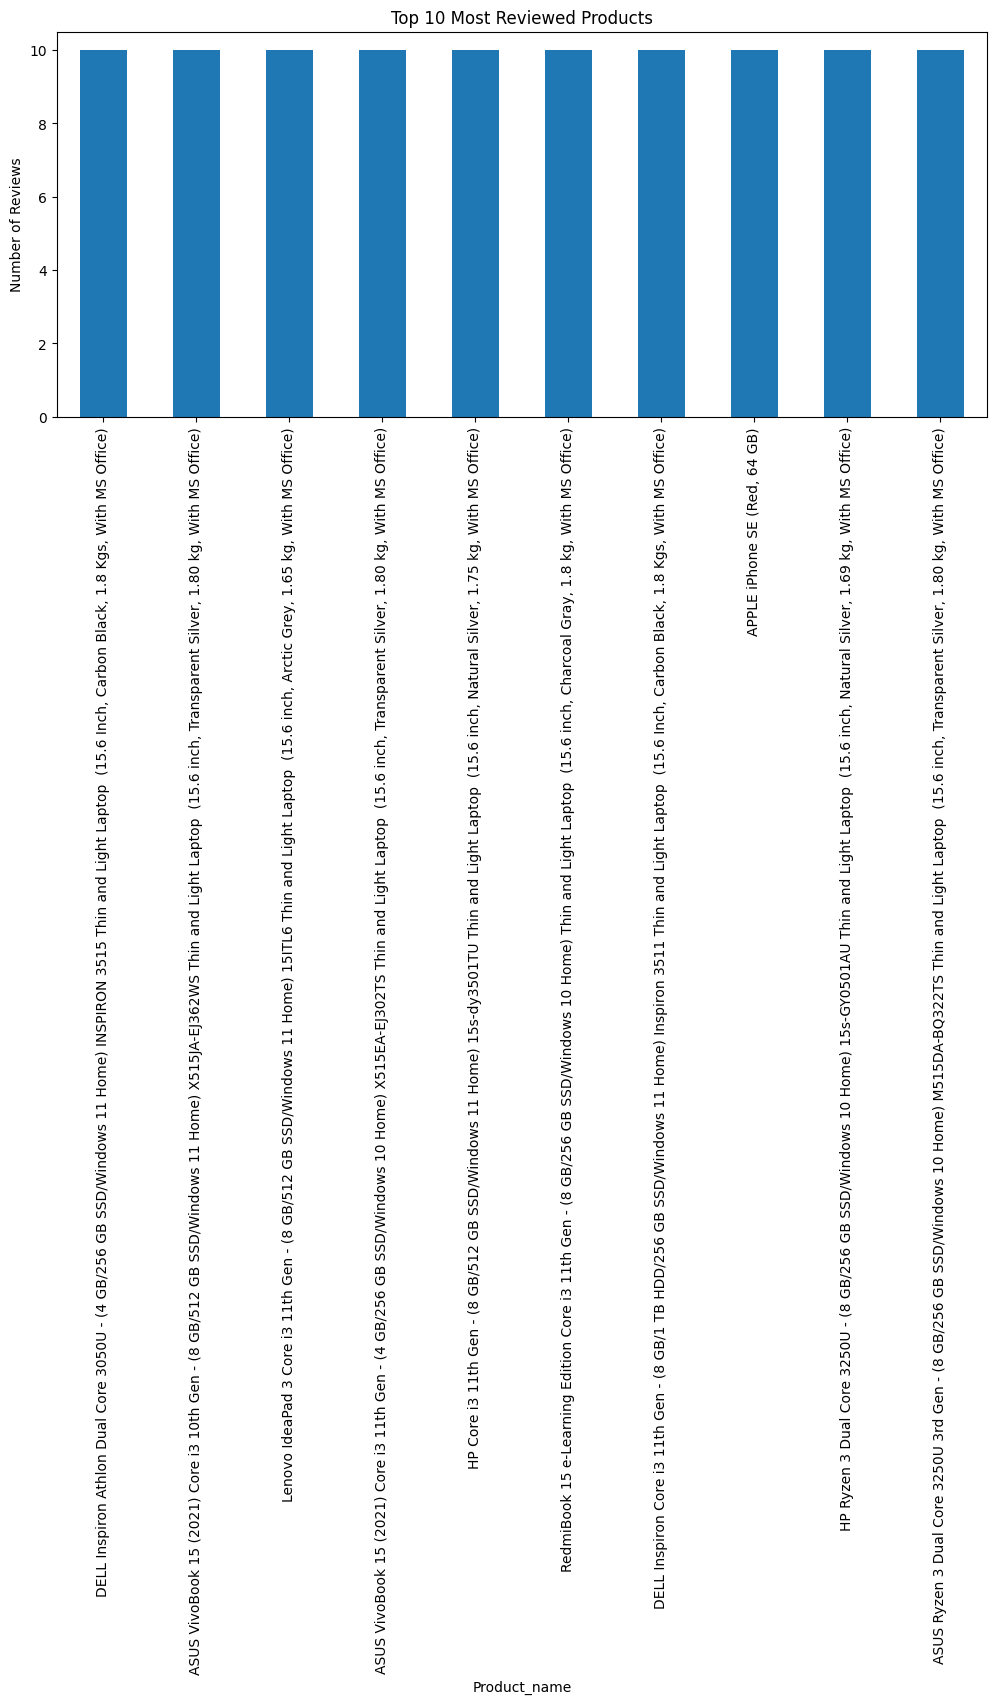

In [ ]:
plt.figure(figsize=(12,5))

df["Product_name"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Reviewed Products")

plt.ylabel("Number of Reviews")

plt.show()

Rating Distribution

In [ ]:
df["Rating"].value_counts().sort_index()

,count
Rating,
1,162
2,44
3,118
4,525
5,1332


Text Preprocessing (NLP)

In [ ]:
df["Review"].sample(10, random_state=42)

,Review
286,Pros : 1. Colour and design.2. Big display at ...
483,Good product. Fast delivery
1072,awesome
1263,11i 5g mobiles performance and operating very ...
512,good
500,Quite Happy with the delivery ! This fridge lo...
420,"Nice body fridge, osm color i like performance..."
2134,Display is excellent. Good amount of brightnes...
1079,Front camera very poor quality
1159,Nice


In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

NLTK resources

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Create the Lemmatizer

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Keep negation words
stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("nor")

Text Cleaning Function

In [ ]:
def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = text.strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words
    return " ".join(words)

Cleaning Function

In [ ]:
df["Clean_Review"] = df["Review"].apply(clean_text)

Compare Before vs After

In [ ]:
df[["Review", "Clean_Review"]].head(10)

,Review,Clean_Review
0,Best under 60k Great performanceI got it for a...,best k great performancei got around battery b...
1,Good perfomence...,good perfomence
2,Great performance but usually it has also that...,great performance usually also gaming laptop i...
3,My wife is so happy and best product 👌🏻😘,wife happy best product 👌🏻😘
4,"Light weight laptop with new amazing features,...",light weight laptop new amazing feature batter...
5,"Amazing laptop, am so much happy, thanks for F...",amazing laptop much happy thanks flipkart
6,Over all a good laptop for personal use,good laptop personal use
7,Thank you so much Flipkart,thank much flipkart
8,Amazing product,amazing product
9,"Good for normal work , students, online classe...",good normal work student online class watching...


Check Empty Reviews

In [ ]:
df[df["Clean_Review"].str.len() == 0]

,Product_name,Review,Rating,Sentiment,Review_Length,Clean_Review


In [ ]:
print(df.shape)
df.head()

(2181, 6)


,Product_name,Review,Rating,Sentiment,Review_Length,Clean_Review
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,Positive,324,best k great performancei got around battery b...
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,Positive,18,good perfomence
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,Positive,215,great performance usually also gaming laptop i...
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,Positive,40,wife happy best product 👌🏻😘
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,Positive,71,light weight laptop new amazing feature batter...


In [ ]:
df.to_csv("cleaned_flipkart_reviews.csv", index=False)

In [ ]:
print(clean_text("not good"))
print(clean_text("not bad"))
print(clean_text("not worth buying"))

not good
not bad
not worth buying
